In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

dirname = '../data/Health_Dataset/'
filename = 'health_dataset.csv'
data = pd.read_csv(dirname + filename)

In [13]:
from sklearn.model_selection import train_test_split

data = data.dropna()
data = data[data['Life_satisfaction'] <= 10]

X = data.drop(columns=['Life_satisfaction'])
X = pd.get_dummies(X)
y = data['Life_satisfaction']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=3000)
model.fit(X_train, y_train)

# print training accuracy
print("Training accuracy: ", model.score(X_train, y_train))
print("Test accuracy: ", model.score(X_test, y_test))

Training accuracy:  0.30729830467716723
Test accuracy:  0.30370797864665994


/Users/pengqize/Documents/code/python/mental-health-forecast/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [15]:
# y_pred = model.predict(X_test)

# from sklearn.metrics import accuracy_score
# accuracy = accuracy_score(y_test, y_pred)
# print(f'Accuracy: {accuracy:.2f}')

# from sklearn.metrics import classification_report, confusion_matrix
# print(classification_report(y_test, y_pred))
# cm = confusion_matrix(y_test, y_pred)
# plt.figure(figsize=(10, 7))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
# plt.ylabel('Actual')
# plt.xlabel('Predicted')
# plt.title('Confusion Matrix')
# plt.show()

In [16]:
# Models
# Linear Regression
# Ridge Regression
# Lasso Regression
# Kernel Ridge Regressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.kernel_ridge import KernelRidge

# Random Forest Regressor
# Gradient Boosting Regressor
# Histogram-based Gradient Boosting Regressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.ensemble import HistGradientBoostingRegressor

# Support Vector Regressor (SVR)
from sklearn.svm import SVR

# Multi-layer perceptron (MLP)
from sklearn.neural_network import MLPRegressor

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(),
    # 'Kernel Ridge Regressor': KernelRidge(),
    # 'Random Forest Regressor': RandomForestRegressor(max_depth=10, random_state=42),
    'Gradient Boosting Regressor': GradientBoostingRegressor(),
    'Histogram-based Gradient Boosting Regressor': HistGradientBoostingRegressor(),
    'Support Vector Regressor (SVR)': SVR(),
    'Multi-layer perceptron (MLP)': MLPRegressor(max_iter=1000)
}

Running Linear Regression...
Linear Regression: MSE = -0.38 ± 0.00
Running Ridge Regression...
Ridge Regression: MSE = -0.38 ± 0.00
Running Lasso Regression...
Lasso Regression: MSE = -0.01 ± 0.00
Running Gradient Boosting Regressor...
Gradient Boosting Regressor: MSE = -0.42 ± 0.01
Running Histogram-based Gradient Boosting Regressor...
Histogram-based Gradient Boosting Regressor: MSE = -0.42 ± 0.01
Running Support Vector Regressor (SVR)...
Support Vector Regressor (SVR): MSE = 0.00 ± 0.00
Running Multi-layer perceptron (MLP)...
Multi-layer perceptron (MLP): MSE = 42099.54 ± 83986.27


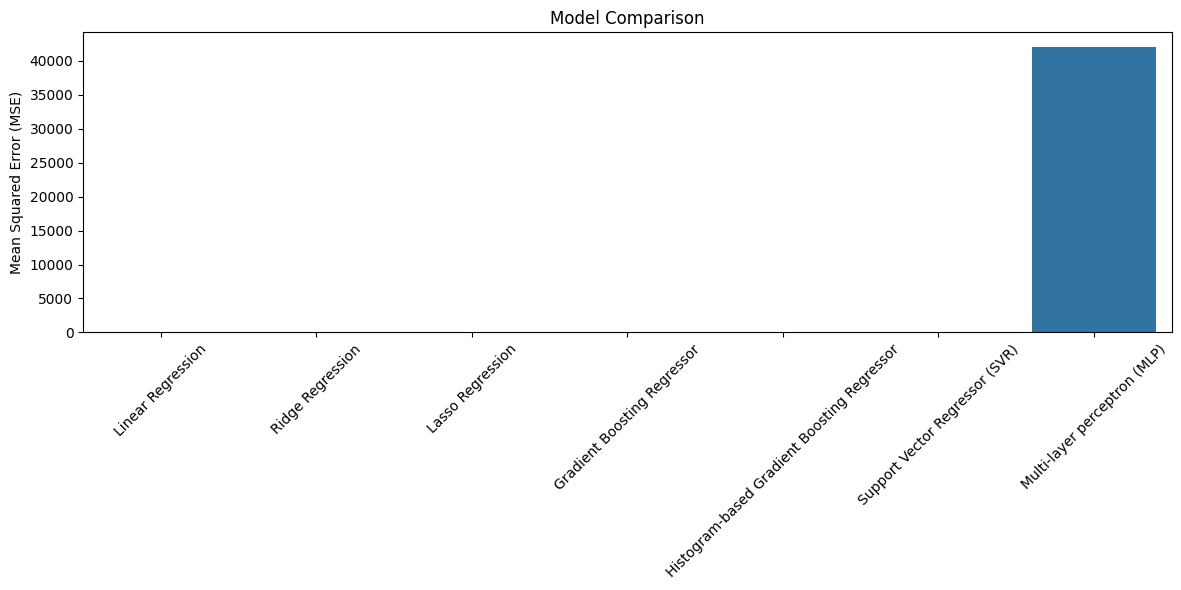

AttributeError: 'MLPRegressor' object has no attribute 'feature_importances_'

In [ ]:
from sklearn.model_selection import cross_val_score
results = {}
for name, model in models.items():
    print(f'Running {name}...')
    score = cross_val_score(model, X_train, y_train, cv=5)
    results[name] = {
        'MSE': -score.mean(),
        'Std': score.std()
    }
    print(f'{name}: MSE = {results[name]["MSE"]:.2f} ± {results[name]["Std"]:.2f}')

# Plotting the results
plt.figure(figsize=(12, 6))
sns.barplot(x=list(results.keys()), y=[result['MSE'] for result in results.values()])
plt.xticks(rotation=45)
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Model Comparison')
plt.tight_layout()
plt.show()